In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
# === Load CSV ===
csv_file = "GestureDataset.csv"   # <-- your actual file name
df = pd.read_csv(csv_file, header=None)

# Split into labels and features
y = df.iloc[:, 0].values          # first column = labels
X = df.iloc[:, 1:].values         # rest = pixels

# Normalize pixel values (if not already 0–1)
X = X / 255.0

In [3]:
# === Handle Non-sequential Labels (like 0, 2, 13) ===
unique_labels = sorted(np.unique(y))
label_map = {old: new for new, old in enumerate(unique_labels)}
print("🔢 Label mapping:", label_map)

y_mapped = np.array([label_map[val] for val in y])

# === Train-test Split (80/20) ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y_mapped, test_size=0.2, random_state=42, stratify=y_mapped
)

# One-hot encode labels
num_classes = len(unique_labels)
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

🔢 Label mapping: {np.float64(0.0): 0, np.float64(2.0): 1, np.float64(13.0): 2}


In [4]:
# === Build Neural Network ===
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X.shape[1],)),    # Input layer
    tf.keras.layers.Dense(256, activation='relu'), # Hidden layer
    tf.keras.layers.Dense(num_classes, activation='softmax') # Output layer
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# === Early Stopping (stop when model converges) ===
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

In [5]:
# === Train Model ===
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,            # Will stop early when converged
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


75/75 [==============================] - 9s 92ms/step - loss: 1.1022 - accuracy: 0.3596 - val_loss: 1.0949 - val_accuracy: 0.3983
Epoch 2/100
75/75 [==============================] - 6s 85ms/step - loss: 1.0883 - accuracy: 0.3904 - val_loss: 1.0819 - val_accuracy: 0.4150
Epoch 3/100
75/75 [==============================] - 6s 83ms/step - loss: 1.0682 - accuracy: 0.4338 - val_loss: 1.0669 - val_accuracy: 0.4533
Epoch 4/100
75/75 [==============================] - 6s 85ms/step - loss: 1.0493 - accuracy: 0.4625 - val_loss: 1.0486 - val_accuracy: 0.4550
Epoch 5/100
75/75 [==============================] - 6s 84ms/step - loss: 1.0266 - accuracy: 0.4954 - val_loss: 1.0451 - val_accuracy: 0.4200
Epoch 6/100
75/75 [==============================] - 6s 85ms/step - loss: 1.0188 - accuracy: 0.4667 - val_loss: 1.0344 - val_accuracy: 0.4733
Epoch 7/100
75/75 [==============================] - 6s 84ms/step - loss: 0.9934 - accuracy: 0.5042 - val_loss: 1.0150 - val_accuracy: 0.4783
Epoc

19/19 [==============================] - 0s 14ms/step - loss: 0.4720 - accuracy: 0.8183

 Test Accuracy: 0.8183
 Test Loss: 0.4720


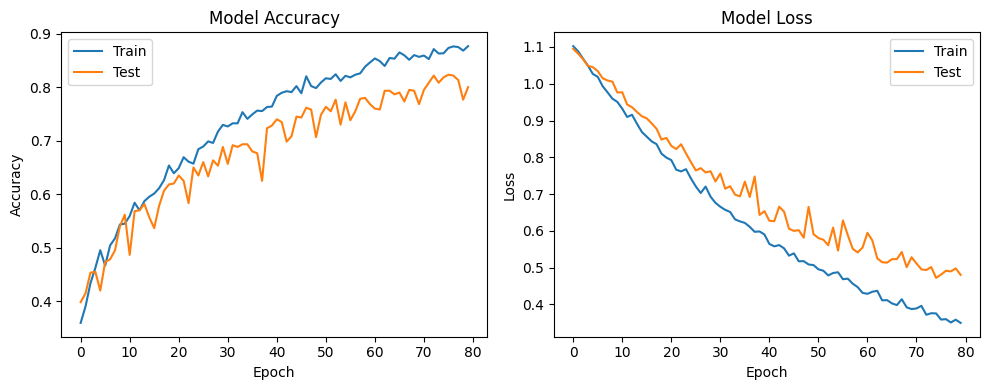

c:\Python\Lib\site-packages\tf_keras\src\engine\training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


 Model saved as gesture_ann_model.h5


In [6]:
# === Evaluate Model ===
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n Test Accuracy: {test_acc:.4f}")
print(f" Test Loss: {test_loss:.4f}")

# === Plot Accuracy & Loss ===
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Test')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# === Save Model (optional) ===
model.save("gesture_ann_model.h5")
print(" Model saved as gesture_ann_model.h5")